Funathon NACE code classifier
URL: https://aiml4os.github.io/funathon-project2/1-ttc.html

*1. Install the dependencies*
All required packages are listed in pyproject.toml. Run the following command once at the root of the project to install them into a virtual environment:

In [30]:
uv sync

Resolved 190 packages in 1ms
Checked 183 packages in 2ms
Note: you may need to restart the kernel to use updated packages.


*1.3. Start an MLflow service*

Launch an MLflow service from the SSP Cloud service catalogue. To do so, go on SSPCloud, click on My Services, then on New Service, then on Automation, then on MLflow, then on Launch. Once the service starts, its public URL appears in the service details. It typically looks like https://user-<username>-mlflow.user.lab.sspcloud.fr.

Create a file named .env at the root of the project and fill it in as follows:

MLFLOW_TRACKING_URI=<add the MLflow server URL>
MLFLOW_TRACKING_USERNAME=<add your username>
MLFLOW_TRACKING_PASSWORD=<add your password>

*2 Load the data*
The dataset consists of synthetic labelled examples generated for the NACE rev 2.1 nomenclature. Each row contains a short text description (label) and the corresponding NACE code (code).

*2.1 Question 1 — Import libraries and load environment variables*
Import the package mlflow and the load_dotenv from the dotenv package. Then execute load_dotenv(override=True) to load your .env file.

In [31]:
import os
import mlflow
from dotenv import load_dotenv

load_dotenv(override=True)

True

*2.2 Question 2 — Load the dataset from s3*
Use Polars to load the parquet file directly from this public URL:

https://minio.lab.sspcloud.fr/projet-formation/diffusion/funathon/2026/project2/generation_None_temp08.parquet
Print the first rows and the total number of observations. Do you understand all columns?

In [32]:
import polars as pl

df = pl.read_parquet("https://minio.lab.sspcloud.fr/projet-formation/diffusion/funathon/2026/project2/generation_None_temp08.parquet")

In [33]:
print(df.head(10))

shape: (10, 3)
┌───────┬─────────────────────────────────┬─────────────────────────────────┐
│ code  ┆ name                            ┆ label                           │
│ ---   ┆ ---                             ┆ ---                             │
│ str   ┆ str                             ┆ str                             │
╞═══════╪═════════════════════════════════╪═════════════════════════════════╡
│ 01.11 ┆ Growing of cereals, other than… ┆ Pulses cultivation for market   │
│ 01.11 ┆ Growing of cereals, other than… ┆ Legume crop production activit… │
│ 01.11 ┆ Growing of cereals, other than… ┆ Broad bean farming operations   │
│ 01.11 ┆ Growing of cereals, other than… ┆ Chickpea harvesting and proces… │
│ 01.11 ┆ Growing of cereals, other than… ┆ Production of dried beans and … │
│ 01.11 ┆ Growing of cereals, other than… ┆ Commercial cultivation of lent… │
│ 01.11 ┆ Growing of cereals, other than… ┆ Cowpea yield and quality contr… │
│ 01.11 ┆ Growing of cereals, other than… ┆ Pigeo

In [34]:
print(f"Total rows: {len(df)}")

Total rows: 70000


*2.3 Question 3 — Count unique NACE codes*
How many unique NACE codes are present in the dataset? Store this number in a variable called n_classes. This number will define the number of output classes the model must predict.

In [35]:
n_classes = df['code'].n_unique()
print(f"Number of unique NACE codes: {n_classes}")

Number of unique NACE codes: 311


*3 Split the data*
Before training a model, we need to split the dataset into three subsets:

- Train: the examples the model learns from.
- Validation: used during training to monitor performance and trigger early stopping (i.e. stop training before overfitting).
- Test: held out until the very end to give an unbiased estimate of the model’s performance on unseen data.

Why three splits and not two?
Using the validation set to tune hyperparameters or stop training means it indirectly influences the model. The test set must therefore remain completely untouched during training so that the final evaluation is truly unbiased.

*3.1 Question 1 — Split the dataset into train / validation / test sets*
Use train_test_split from sklearn.model_selection to split the dataset into train, validation, and test sets (70% / 15% / 15%). Do not forget to choose a random_state. Separate the target y from the features X, and convert them to numpy arrays. You should obtain objects X_train, y_train, and so on.

In [36]:
from sklearn.model_selection import train_test_split

train_df, tmp_df = train_test_split(df, test_size=0.30, random_state=42)
val_df, test_df  = train_test_split(tmp_df, test_size=0.50, random_state=42)

X_train, y_train = train_df["label"].to_numpy(), train_df["code"].to_numpy()
X_val, y_val = val_df["label"].to_numpy(), val_df["code"].to_numpy()
X_test, y_test = test_df["label"].to_numpy(), test_df["code"].to_numpy()

In [37]:

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 49000 | Val: 10500 | Test: 10500


*3.2 Question 2 — Encode the labels*
The code column contains strings like "47.11A" (codes from the NACE classification). Neural networks do not understand strings and require integer targets (1, 2, 3…), so we need to map each unique NACE code to an integer index. To do that, you will use an encoder.

Use LabelEncoder from sklearn.preprocessing (see here for the documentation). Call .fit() on the code column of your training dataframe (after having converted it to a numpy array with .to_numpy()).

We use LabelEncoder to map the categorical target y to integers 0, 1, …, n_classes - 1, the format expected by scikit-learn classifiers.

Fit the LabelEncoder on the training set only — fitting on validation or test data would be data leakage. However, this means any NACE code absent from the training set will cause an error at inference time. Make sure every code appears at least once in training before splitting.

In [38]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
encoder.fit(train_df['code'].to_numpy())

LabelEncoder()

In [39]:
all_codes  = set(df['code'])
train_codes = set(train_df['code'])
missing = all_codes - train_codes

if missing:
    print(f"WARNING: {len(missing)} code(s) missing from training set: {missing}")
else:
    print(f"OK — all {len(all_codes)} codes appear in the training set.")

OK — all 311 codes appear in the training set.


*3.3 Question 3 — Prepare the labels to use them with ttc*
torchTextClassifiers requires labels to be wrapped in a ValueEncoder object. This is straightforward: you just pass your already-fitted LabelEncoder to the ValueEncoder constructor.

Import the ValueEncoder class from the torchTextClassifiers.value_encoder subpackage, then create a value_encoder object by passing your fitted label_encoder as an argument.

While LabelEncoder plays the role of the “converter” from string labels to integers, working with raw integers at prediction time can be cumbersome — you have to manually map predictions back to their original label names. The ValueEncoder solves this by integrating tightly with the torchTextClassifiers ecosystem: when you pass it to a model, predictions are automatically returned as human-readable labels rather than integers. As a bonus, ValueEncoder also supports additional categorical input features — advanced readers can find examples here. https://inseefrlab.github.io/torchTextClassifiers/tutorials/mixed_features.html

In [ ]:
# %pip install git+https://github.com/InseeFrLab/torchTextClassifiers.git

  Cloning https://github.com/InseeFrLab/torchTextClassifiers.git to /tmp/pip-req-build-ib3nbhy7
  Running command git clone --filter=blob:none --quiet https://github.com/InseeFrLab/torchTextClassifiers.git /tmp/pip-req-build-ib3nbhy7
ERROR: Operation cancelled by user
^C
Note: you may need to restart the kernel to use updated packages.


In [41]:
from torchTextClassifiers.value_encoder import ValueEncoder

value_encoder = ValueEncoder(label_encoder=encoder)

*4 Applying a tokenizer*
*4.1 Why tokenization?*
Neural networks can only work with numbers because they have no notion of letters or words. As a a consequence, models cannot use directly the string “I sell croissants and pains au chocolat” to predict a NACE code, it must be transformed into something the model can use. A tokenizer is the component that bridges this gap: it converts raw text into a sequence of integers that the model can process.

The process has three steps:

1. Split the text into small units called tokens: these can be whole words, subword fragments, or individual characters.
2. Map each token to a unique integer using a fixed vocabulary (a lookup table built during training).
3. Pad or truncate the resulting sequence to a fixed length so that all inputs have the same shape, which is required for batched training.

*4.2 Why subword tokenization?*
There are several ways to split text into tokens: by character, by full word, or by subword fragment.

Strategy	Example for “croissants”	Problem
Character-level	["c","r","o","i","s","s","a","n","t","s"]	Sequences become very long; meaning is hard to capture
Word-level	["croissants"]	Rare or misspelled words get mapped to [UNKNOWN]
Subword (WordPiece)	["croi", "##ssants"]	Handles rare words without losing common subparts

WordPiece, the algorithm used here, builds a vocabulary of frequent subword units from the training corpus. Words it has never seen can still be represented by combining known fragments. The ## prefix marks a fragment that continues the previous token (i.e. it is not the start of a new word).

Because the vocabulary is learned from your data, it naturally adapts to domain-specific vocabulary; in our case, French business descriptions full of technical terms.

The Hugging Face tokenizer documentation gives a clear overview of the main tokenization strategies (BPE, WordPiece, Unigram). 
https://huggingface.co/docs/transformers/tokenizer_summary

The Hugging Face tokenizers course chapter is a hands-on introduction for beginners. 
https://huggingface.co/learn/nlp-course/chapter6/1

*4.3 Question 1 — Train the tokenizer and inspect a sample*
You are going to use a WordPieceTokenizer from the torchTextClassifiers package (see the documentation). Train a WordPieceTokenizer from scratch on the training labels with vocab_size=5000 and output_dim=10. Use the fitted tokenizer to tokenize one observations (with the tokenize method), and inspect the result to understand how the text is split.

Always train the tokenizer on X_train only — never on the validation or test sets. Using the full dataset would mean the tokenizer has seen vocabulary from examples the model is supposed to predict.

In [42]:
import sys
import traceback

print("Python:", sys.executable)
print()

try:
    from tokenizers import Tokenizer
    print("tokenizers import: OK")
except Exception:
    print("tokenizers import: FAILED")
    traceback.print_exc()

print()

try:
    from transformers import AutoTokenizer, PreTrainedTokenizerFast
    print("transformers import: OK")
except Exception:
    print("transformers import: FAILED")
    traceback.print_exc()

Python: /opt/python/bin/python

tokenizers import: OK

transformers import: OK


In [43]:
import sys

for module_name in list(sys.modules):
    if module_name == "torchTextClassifiers.tokenizers" or module_name.startswith(
        "torchTextClassifiers.tokenizers."
    ):
        del sys.modules[module_name]

from torchTextClassifiers.tokenizers import HAS_HF, WordPieceTokenizer

print("HAS_HF:", HAS_HF)

tokenizer = WordPieceTokenizer(vocab_size=5000, output_dim=10)
tokenizer.train(X_train)

HAS_HF: True





In [44]:
from torchTextClassifiers.tokenizers import WordPieceTokenizer

tokenizer = WordPieceTokenizer(vocab_size=5000, output_dim=10)
tokenizer.train(X_train)

In [45]:

print("Output tensor size:", tokenizer.tokenize(X_train[0]).input_ids.shape)
print("Vocabulary size:", tokenizer.vocab_size)

# Look at an example of tokenization
print("Raw text", X_train[0])
print(
    "Tokens id:",
    tokenizer.tokenize(X_train[0]).input_ids.squeeze(0)
)
print(
    "Tokens:",
    tokenizer.tokenizer.convert_ids_to_tokens(
        tokenizer.tokenize(X_train[0]).input_ids.squeeze(0)
    )
)

Output tensor size: torch.Size([1, 10])
Vocabulary size: 5000
Raw text Real estate portfolio management
Tokens id: tensor([  3, 190, 206, 317, 137,   2,   1,   1,   1,   1])
Tokens: ['[SEP]', 'real', 'estate', 'portfolio', 'management', '[CLS]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


*5 Model architecture*

https://inseefrlab.github.io/torchTextClassifiers/architecture/overview.html#component-4-classification-head

A text classification model in torchTextClassifiers is built from three components (on top of the ValueEncoder and the tokenizer seen above):

1. TextEmbedder: converts token IDs into dense vectors (embeddings) of size embedding_dim.

The problem: computers can’t work with words directly — they need numbers. A naive solution is to assign each word a unique integer (its token ID). But this is useless for learning: the number 2345 tells the model nothing about what “cat” means, and gives no hint that “cat” and “kitten” should be treated similarly.

The idea: instead of a single integer, represent each token as a dense vector — a list of, say, 768 floating-point numbers. This vector is the word’s embedding: its coordinates in a high-dimensional “semantic space”.

Where do these numbers come from? The embedding vectors are learned parameters of the model, initialised randomly and updated during training just like any other weight. The training signal pushes the model to give similar vectors to words that behave similarly in context. After training, words with related meanings end up close together in embedding space.

Words projected into a 2D embedding space — similar concepts cluster together

Words projected into a 2D embedding space — similar concepts cluster together
A memorable analogy: think of each word as a point on a map. Cities in the same country end up near each other; animals cluster together; food words form their own neighbourhood. The “distance” between two points reflects how semantically related the words are. This is why you can do things like:

The geometry of the space encodes meaning.

In torchTextClassifiers: the TextEmbedder component takes a sequence of token IDs and looks up each one in a learnable embedding matrix (of shape vocab_size × embedding_dim), producing a sequence of dense vectors that the rest of the network can reason about.

2. CategoricalVariableNet (optional): encodes additional categorical features and merges them with the text representation. Not used here.

3. ClassificationHead: projects the final representation onto num_classes dimensions. The highest value determines the predicted class.

To learn more about the building blocks of the torchTextClassifiers package, please visit the documentation. https://inseefrlab.github.io/torchTextClassifiers/architecture/index.html

These are configured through ModelConfig and assembled automatically by torchTextClassifiers. You can see some ModelConfig examples here https://inseefrlab.github.io/torchTextClassifiers/architecture/overview.html#usage-examples and for torchTextClassifiers here. https://inseefrlab.github.io/torchTextClassifiers/api/wrapper.html

*6 Training*
Training a neural network means finding the weights that minimise a loss function — a measure of how wrong the model’s predictions are. At each step, the model makes predictions on a mini-batch of examples, computes the loss, and updates the weights in the direction that reduces it (via an optimization algorithm called the stochastic gradient descent).

Key training hyperparameters:

- num_epochs: how many times the model sees the full training set.
- batch_size: how many examples are processed at once before a weight update.
- lr (learning rate): how large each weight update step is.
- patience_early_stopping: stop training if the validation loss has not improved for this many epochs, to avoid overfitting.

torchTextClassifiers provides a high-level wrapper that combines the value encoder, tokenizer, model components, and training loop. You will do two things: create a model, and then train the model. It is important to distinguish these two steps clearly. To do so, torchTextClassifiers offers two tools: ModelConfig defines the model and TrainingConfig defines the training process.

*6.1 Question 1 — Create the classifier*
Using the torchTextClassifiers package, create a ModelConfig. Then create a torchTextClassifiers classifier that uses this ModelConfig and the trained tokenizer. Set the dimension of embeddings to 96. You will need to read carefully the torchTextClassifiers documentation. https://inseefrlab.github.io/torchTextClassifiers/api/index.html

The hyperparameter embedding_dim controls the size of the dense vector representing each token. Larger values capture more information but are slower to train.

In [46]:
from torchTextClassifiers import ModelConfig, TrainingConfig, torchTextClassifiers

embedding_dim = 96

model_config = ModelConfig(
    embedding_dim=embedding_dim,
    num_classes=n_classes,)

ttc = torchTextClassifiers(
    tokenizer=tokenizer,
    model_config=model_config,
    value_encoder=value_encoder,
)

2026-05-27 12:29:29 - torchTextClassifiers.model.model - 🔹 No categorical variable network provided; using only text embeddings.


*6.2 Question 2 — Prepare training*
Create a TrainingConfig(lr=..., batch_size=..., num_epochs=...). Look at the documentation. Do you understand what each argument does? Use only 1 epoch for fast training.

Of course, you can play with hyperparameters if you want: add more epochs, change the learning rate and the batch size… But remember that you are training the model using CPUs, so avoid big models that will take a lot of time and resources to train.

Key hyperparameters used here:

- lr=5e-4: a standard starting learning rate for Adam-based optimizers.
- batch_size=128: how many examples are processed before each weight update — larger batches are faster but require more memory.
- num_epochs=1: one pass over the data, kept short for this demo.

In [57]:
training_config = TrainingConfig(
    num_epochs=5,
    batch_size=128,
    lr=5 * 1e-4,
    patience_early_stopping=5,
)

*6.3 Question 3 — Train on a small subsample*
Train the model using the TrainingConfig defined before. Look carefully at the arguments of the train method. You can try to use MLflow or automatic model logging, but this is optional (see below).

In [ ]:
mlflow.set_experiment("funathon-2026-project2")
mlflow.pytorch.autolog()

with mlflow.start_run() as run:
    # This should take approximately 1-2mn
    ttc.train(
        X_train,
        y_train,
        training_config=training_config,
        X_val=X_val,
        y_val=y_val,
        verbose=True,
    )

    mlflow.log_artifacts(
        training_config.save_path,   # local folder produced by ttc.train()
        artifact_path="model_artifacts",
    )

2026-05-27 12:32:55 - torchTextClassifiers.torchTextClassifiers - Starting training process...
2026-05-27 12:32:55 - torchTextClassifiers.torchTextClassifiers - Running on: cpu
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-05-27 12:32:55 - torchTextClassifiers.torchTextClassifiers - Launching training...
2026/05/27 12:32:55 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/opt/python/lib/python3.13/site-packages/mlflow/pytorch/_lightning_autolog.py:542: UserWarning: Autologging is known to be compatible with pytorch-lightning versions between 2.2.4 and 2.6.1 and may not succeed with packages outside this range."


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type                    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model       │ TextClassificationModel │  546 K │ eval  │     0 │
│ 1 │ loss        │ CrossEntropyLoss        │      0 │ train │     0 │
│ 2 │ accuracy_fn │ MulticlassAccuracy      │      0 │ train │     0 │
└───┴─────────────┴─────────────────────────┴────────┴───────┴───────┘

Trainable params: 546 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 546 K                                                                                                
Total estimated model params size (MB): 2.187                                                                      
Modules in train mode: 2                                                                                           
Modules in eval mode: 12                                                                                           
Total FLOPs: 0

/opt/python/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/opt/python/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/opt/python/lib/python3.13/site-packages/pytorch_lightning/loops/fit_loop.py:538: Found 12 module(s) in eval mode 
at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can 
ignore this warning.

*7 Prediction and explainability*
Once the model is trained, we can use it to predict NACE codes for new text descriptions. Beyond a simple prediction, we also want to understand why a given NACE code was predicted — specifically, which words in the input text contributed the most to the decision. To understand which words influenced a prediction, we use a technique called integrated gradients (via Captum’s LayerIntegratedGradients). It assigns a score to each word in the input: a high score means that word pushed the model toward the predicted class. You can refer to this tutorial on explainability for more details. https://inseefrlab.github.io/torchTextClassifiers/tutorials/explainability.html

Scores based on integrated gradients are a useful guide, not a definitive explanation. Treat them as a way to explore the model’s behavior, not as proof of causality.

*7.1 Question 0 — Load the pretrained model from MLflow*
We provide a pretrained model trained on the full dataset with many epochs. Load it using this code:

In [49]:
import s3fs

fs = s3fs.S3FileSystem(
    anon=True,  # public bucket
    endpoint_url="https://minio.lab.sspcloud.fr",
)

local_dir = "./mlflow-artifacts/"
fs.get(
    "projet-funathon/diffusion/mlflow-artifacts/",
    local_dir,
    recursive=True,
)
# Rebuild the torchTextClassifiers object from the downloaded files
ttc = torchTextClassifiers.load(local_dir)

ttc.pytorch_model.eval()

2026-05-27 12:29:59 - torchTextClassifiers.model.model - 🔹 No categorical variable network provided; using only text embeddings.
2026-05-27 12:29:59 - torchTextClassifiers.torchTextClassifiers - Model checkpoint loaded from mlflow-artifacts/model_checkpoint.ckpt
2026-05-27 12:29:59 - torchTextClassifiers.torchTextClassifiers - Model loaded successfully from mlflow-artifacts


TextClassificationModel(
  (token_embedder): TokenEmbedder(
    (embedding_layer): Embedding(5000, 96, padding_idx=1)
  )
  (sentence_embedder): SentenceEmbedder(
    (label_attention_module): LabelAttention(
      (label_embeds): Embedding(311, 96)
      (c_q): Linear(in_features=96, out_features=96, bias=False)
      (c_k): Linear(in_features=96, out_features=96, bias=False)
      (c_v): Linear(in_features=96, out_features=96, bias=False)
      (c_proj): Linear(in_features=96, out_features=96, bias=False)
    )
  )
  (classification_head): ClassificationHead(
    (net): Linear(in_features=96, out_features=1, bias=True)
  )
)

*7.2 Question 1 — Generate top-5 predictions with confidence scores*
Sample a few texts from the X_test array into a variable called example_texts. Then call ttc.predict(np.array(example_texts), top_k=5, explain_with_captum=True) and print the main fields of the resulting dictionary. The result is a dictionary with keys prediction, confidence and captum_attributions among others.

In [50]:
import random

random_indices = random.sample(range(len(X_test)), 3)
example_texts = X_test[random_indices]
example_true_codes = y_test[random_indices]
print(example_texts)
top_k = 5


['Application maintenance and support'
 'Residential parcel service provision'
 'Contract crop maintenance operations']


In [51]:
import sys
import captum
from captum.attr import LayerIntegratedGradients

print("Python:", sys.executable)
print("Captum version:", captum.__version__)
print("Captum imported successfully.")

Python: /opt/python/bin/python
Captum version: 0.9.0
Captum imported successfully.


In [52]:
import importlib
from captum.attr import LayerIntegratedGradients

# Reload the specific module where HAS_CAPTUM is defined
ttc_module = importlib.import_module(
    "torchTextClassifiers.torchTextClassifiers"
)

print("Before reload:", ttc_module.HAS_CAPTUM)

importlib.reload(ttc_module)

print("After reload:", ttc_module.HAS_CAPTUM)

Before reload: True
After reload: True


In [53]:
results = ttc.predict(example_texts, top_k=top_k, explain_with_captum=True)
for i, text in enumerate(example_texts):
    predicted_codes = [results["prediction"][i][k] for k in range(top_k)]
    confidence = [results["confidence"][i][k].item() for k in range(top_k)]
    print(f"\nText: {text}")
    print(f"  True code: {example_true_codes[i]}")
    for code, conf in zip(predicted_codes, confidence):
        print(f"  {code}  (confidence: {conf:.3f})")


Text: Application maintenance and support
  True code: 62.10
  62.10  (confidence: 0.790)
  81.10  (confidence: 0.120)
  62.20  (confidence: 0.030)
  85.69  (confidence: 0.020)
  82.10  (confidence: 0.010)

Text: Residential parcel service provision
  True code: 53.20
  53.20  (confidence: 1.000)
  85.59  (confidence: 0.000)
  69.10  (confidence: 0.000)
  96.99  (confidence: 0.000)
  85.20  (confidence: 0.000)

Text: Contract crop maintenance operations
  True code: 01.61
  01.61  (confidence: 0.980)
  01.29  (confidence: 0.010)
  95.31  (confidence: 0.010)
  01.13  (confidence: 0.000)
  62.10  (confidence: 0.000)


*7.3 Question 2 — Visualise word attributions for the top prediction*
Now, we want to retrieve the most important words driving the NACE prediction. During inference, the model computes an attribution score for each token — stored in the captum_attributions field of the results — indicating how much each token contributed to the final decision. To do so:

extract captum_attributions from results;
use map_attributions_to_word() and map_attributions_to_char() to aggregate token-level attribution scores up to the word and character levels;
visualize the resulting attributions with plot_attributions_at_word() and plot_attributions_at_char() from torchTextClassifiers.utilities.plot_explainability.

- captum_attributions: tensor of shape (n_text, top_k, seq_len) — attribution scores per token (how much a token has driven a given prediction).
- offset_mapping: character-level start/end positions of each token in the original string, used to map token-level scores back to characters.
- word_ids: maps each token to its parent word index, used to aggregate token scores at the word level.

In [54]:
from torchTextClassifiers.utilities.plot_explainability import (
    map_attributions_to_char, map_attributions_to_word,
    plot_attributions_at_char, plot_attributions_at_word, figshow,
)

text_idx = 0
top_k_idx = 0
text_sample         = example_texts[text_idx]
offsets             = results["offset_mapping"][text_idx]
word_ids            = results["word_ids"][text_idx]
predicted_code = results["prediction"][text_idx][top_k_idx]

attributions  = results["captum_attributions"][text_idx][top_k_idx] # (seq_len,)

words, word_attributions = map_attributions_to_word(
    attributions.unsqueeze(0), text_sample, word_ids, offsets
)
char_attributions = map_attributions_to_char(attributions.unsqueeze(0), offsets, text_sample)

titles = [f"Attributions for NACE code {predicted_code}"]


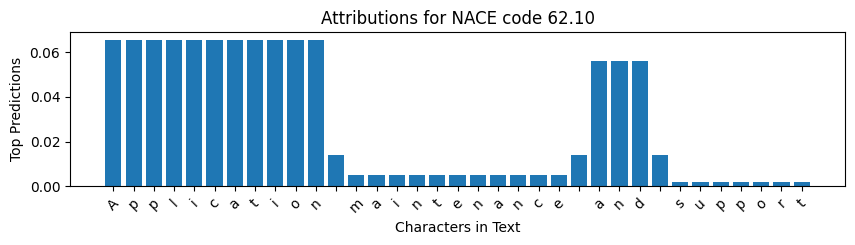

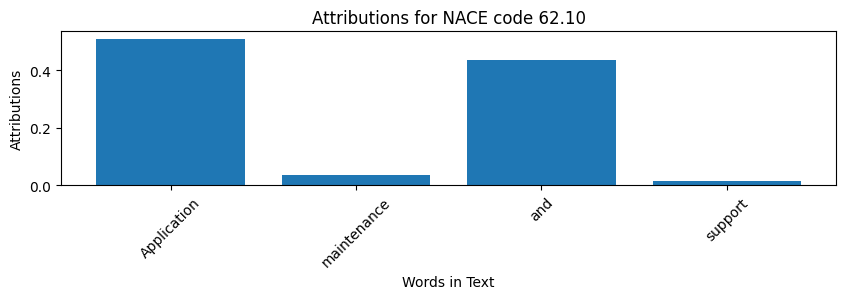

In [55]:

figshow(plot_attributions_at_char(
    text=text_sample, attributions_per_char=char_attributions, titles=titles,
)[0])

figshow(plot_attributions_at_word(
    text=text_sample, words=words.values(), attributions_per_word=word_attributions, titles=titles,
)[0])

*7.4 Question 3 — Evaluate accuracy on the test set*
Run ttc(X_test, top_k=1) and compare the predictions against y_test to compute accuracy.

In [56]:
results_test = ttc.predict(X_test, top_k=1)
preds    = results_test["prediction"].squeeze(1)
accuracy = (preds == y_test).mean()
print(f"Test accuracy: {accuracy:.4f} ({int(accuracy * len(y_test))}/{len(y_test)} correct)")

Test accuracy: 0.8735 (9172/10500 correct)


*7.5 Conclusion*
Not bad at all! The model reaches strong accuracy on the held-out test set — a genuinely production-ready classifier for NACE 2.1 codes.

For production purposes, accuracy is not enough: calibration and robustness metrics matter too. Check out this presentation to read more about the metrics to be checked before trusting a model for production. https://meilame-tayebjee.github.io/IAOS-Vilnius-conference/presentations/accuracy2trust/#/title-slide

In this notebook we learnt how to:

- Load and explore a labelled dataset of business activity descriptions mapped to NACE codes.
- Preprocess the data: split into train, validation, and test sets, and encode the string labels to integers with LabelEncoder.
- Use the torchTextClassifiers package to handle the full workflow: encoding textual labels, training a tokenizer, building a classifier, and explaining its predictions.
- Train a WordPiece tokenizer from scratch on the training corpus, adapting the subword vocabulary to French domain-specific text.
- Configure and train a neural text classifier end-to-end using torchTextClassifiers, with MLflow tracking metrics in real time. https://mlflow.org/docs/latest/index.html
- Load a pretrained model from MLflow artefact storage, so the full-dataset model is available without waiting hours for training.
- Interpret predictions using Captum’s Integrated Gradients to visualise which words drove each classification decision. https://captum.ai/docs/introduction
- Evaluate accuracy on the unseen test set.

DONE! 